# Import libraries

In [21]:
import tensorflow as tf # Access to models, datasets and training
from tensorflow.keras.datasets import cifar100 # Access to CIFAR-100
from tensorflow.keras.applications import ResNet50V2 # Access to pre-trained model
from tensorflow.keras import layers, models, optimizers # Access to building blocks of a model
from tensorflow.keras.models import load_model # Ability to load best_saved model
from tensorflow import keras # Access to stuff for model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard, CSVLogger
from sklearn.model_selection import train_test_split # To help split dataset up
from sklearn.metrics import confusion_matrix, classification_report # Analysis of model train, val & test
import numpy as np # Manipulate data
import pandas as pd # Statistical analysis of data
import seaborn as sns
import matplotlib.pyplot as plt # Plot data
import visualkeras
from PIL import ImageFont # For better font rendering

# Function definitions

In [14]:
def display_imgs_7(imgs, labels):
    plt.figure(figsize = (10,10))
    for i in range(49):
        k = np.random.randint(0, imgs.shape[0])
        plt.subplot(7,7,1+i)
        plt.axis('off')
        plt.imshow(imgs[k], cmap = 'gray')
        plt.xlabel(imgs[k])
    plt.suptitle(f"CIFAR-100 Examples", fontsize=20, y=0.92)


def class_distrib(y, labels_names, dataset_name):
        counts = pd.DataFrame(data=y).value_counts().sort_index()
        #print(f"counts:\n{counts}")
        fig, ax = plt.subplots(figsize=(20,10))
        ax.bar(labels_names, counts)
        ax.set_xticklabels(labels_names, rotation=90, fontsize=15)
        plt.title(f"Distribution of '{dataset_name}' Dataset", fontsize=25)
        plt.grid()
        plt.tight_layout()
        plt.show()

# Displays

In [15]:
#### <<<<<<<<<<Load and process data>>>>>>>>>>
# Load CIFAR-100 dataset
(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode='fine')

# Split (8000) of training data into temporary set
X_temp, X_train, y_temp, y_train = train_test_split(X_train, y_train, test_size=0.84, stratify=y_train, random_state=42)
print(f"X_temp.shape: {X_temp.shape}\n")

# Split temp data into equal validation (4000) and testing (4000) data
X_temp_val, X_temp_test, y_temp_val, y_temp_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print(f"X_temp_val.shape: {X_temp_val.shape}")
print(f"y_temp_val.shape: {y_temp_val.shape}")
print(f"X_temp_test.shape: {X_temp_test.shape}")
print(f"y_temp_test.shape: {y_temp_test.shape}\n")

# Split test data into validation (5000) and testing (5000)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, stratify=y_test, random_state=42)

# Add temp_val to validation (9000) and temp_test to testing (9000) to get a 70/15/15 data split
X_val = np.concatenate((X_val, X_temp_val), axis=0)
y_val = np.concatenate((y_val, y_temp_val), axis=0)
X_test = np.concatenate((X_test, X_temp_test), axis=0)
y_test = np.concatenate((y_test, y_temp_test), axis=0)

print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_val.shape: {X_val.shape}")
print(f"y_val.shape: {y_val.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_test.shape: {y_test.shape}\n")

X_temp.shape: (8000, 32, 32, 3)

X_temp_val.shape: (4000, 32, 32, 3)
y_temp_val.shape: (4000, 1)
X_temp_test.shape: (4000, 32, 32, 3)
y_temp_test.shape: (4000, 1)

X_train.shape: (42000, 32, 32, 3)
y_train.shape: (42000, 1)
X_val.shape: (9000, 32, 32, 3)
y_val.shape: (9000, 1)
X_test.shape: (9000, 32, 32, 3)
y_test.shape: (9000, 1)



C:\Users\andre\AppData\Local\Temp\ipykernel_31204\1521307851.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


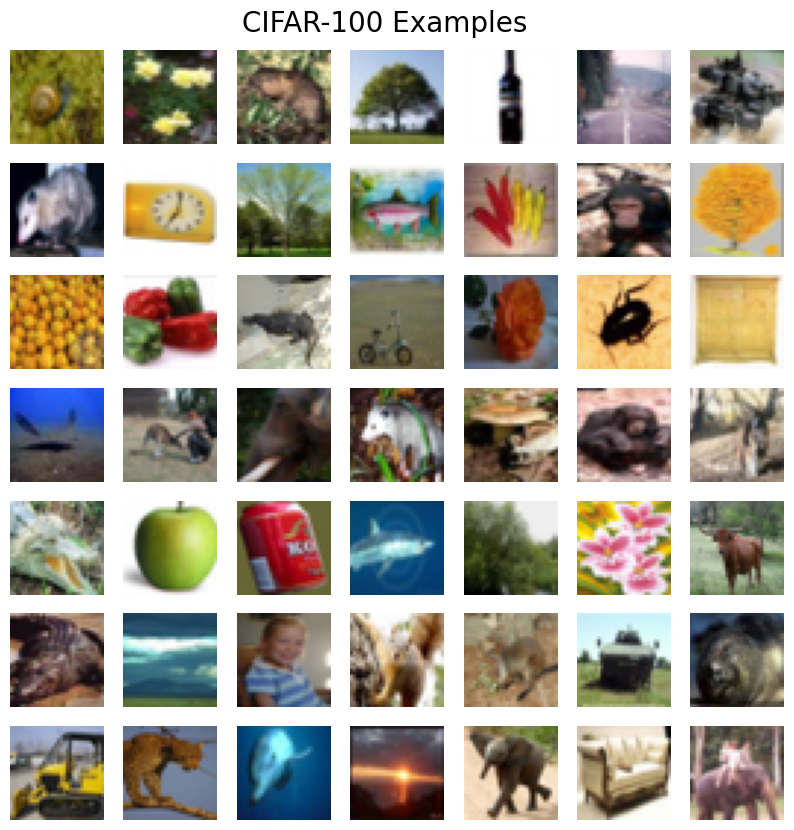

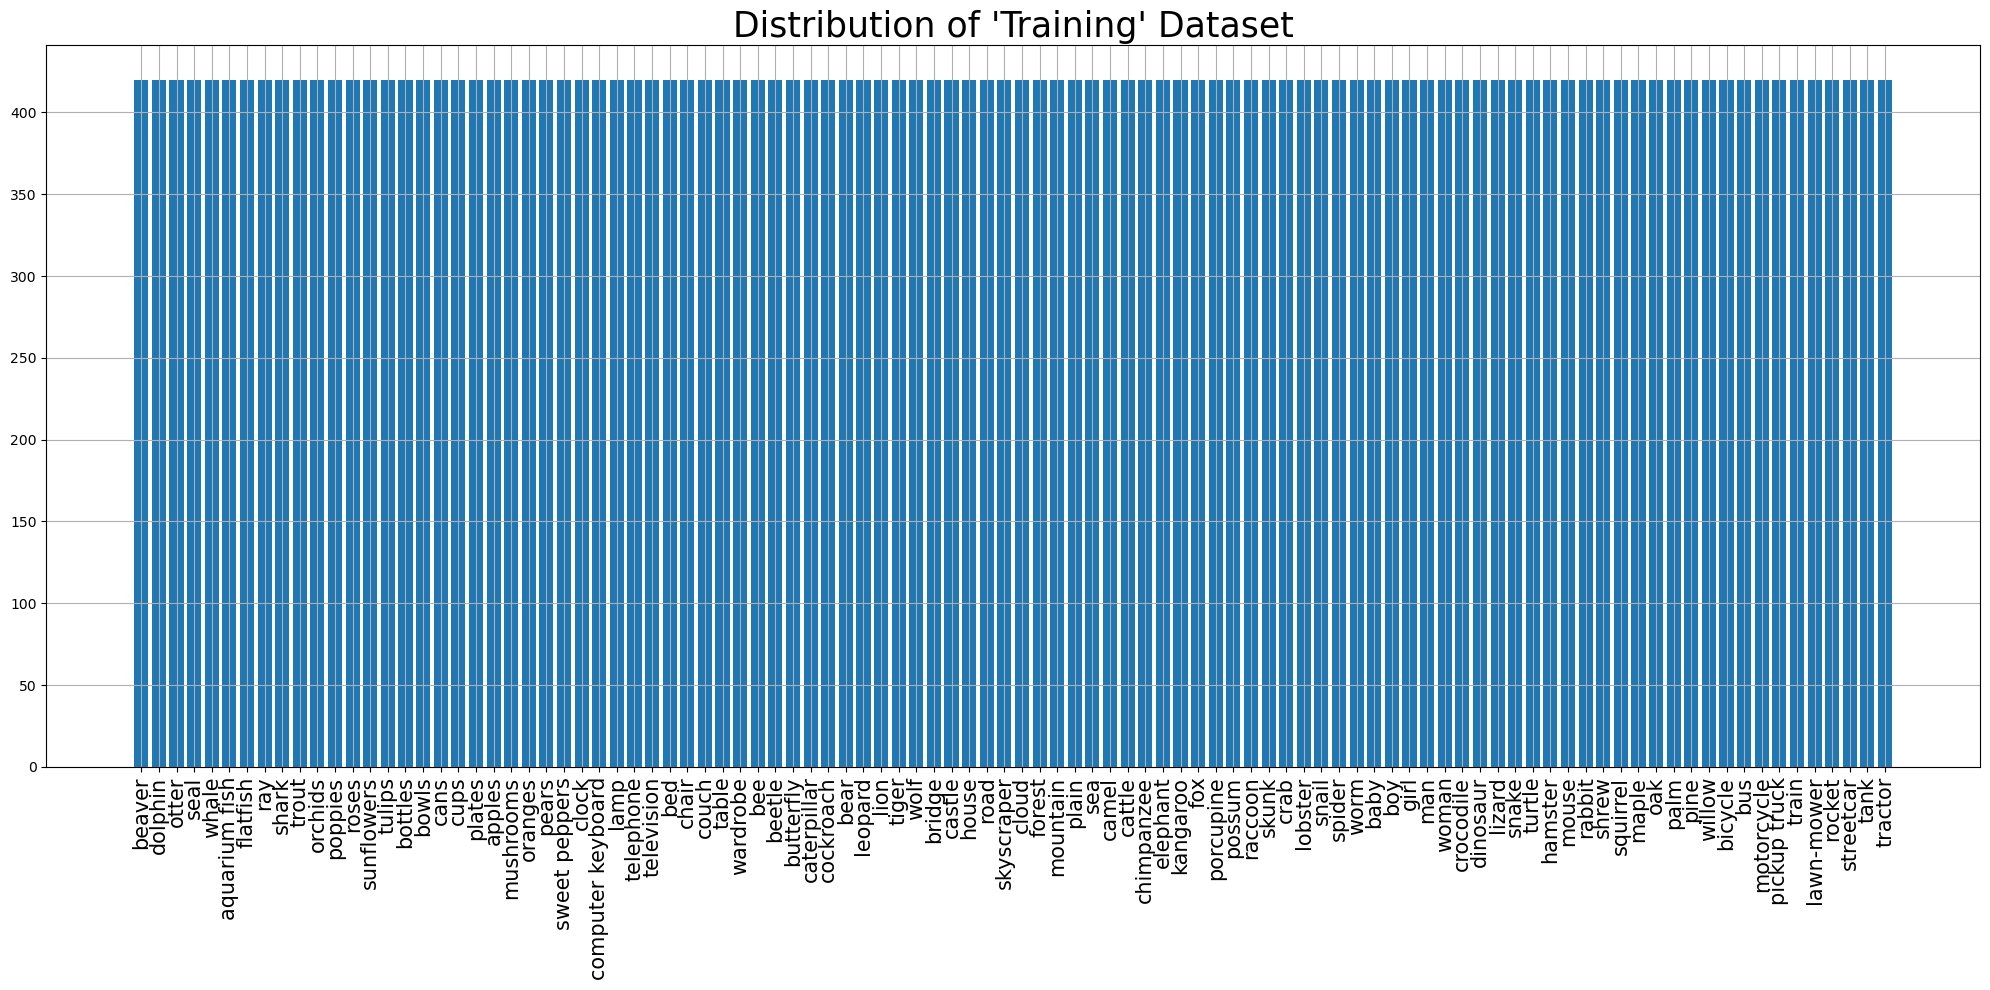

C:\Users\andre\AppData\Local\Temp\ipykernel_31204\1521307851.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


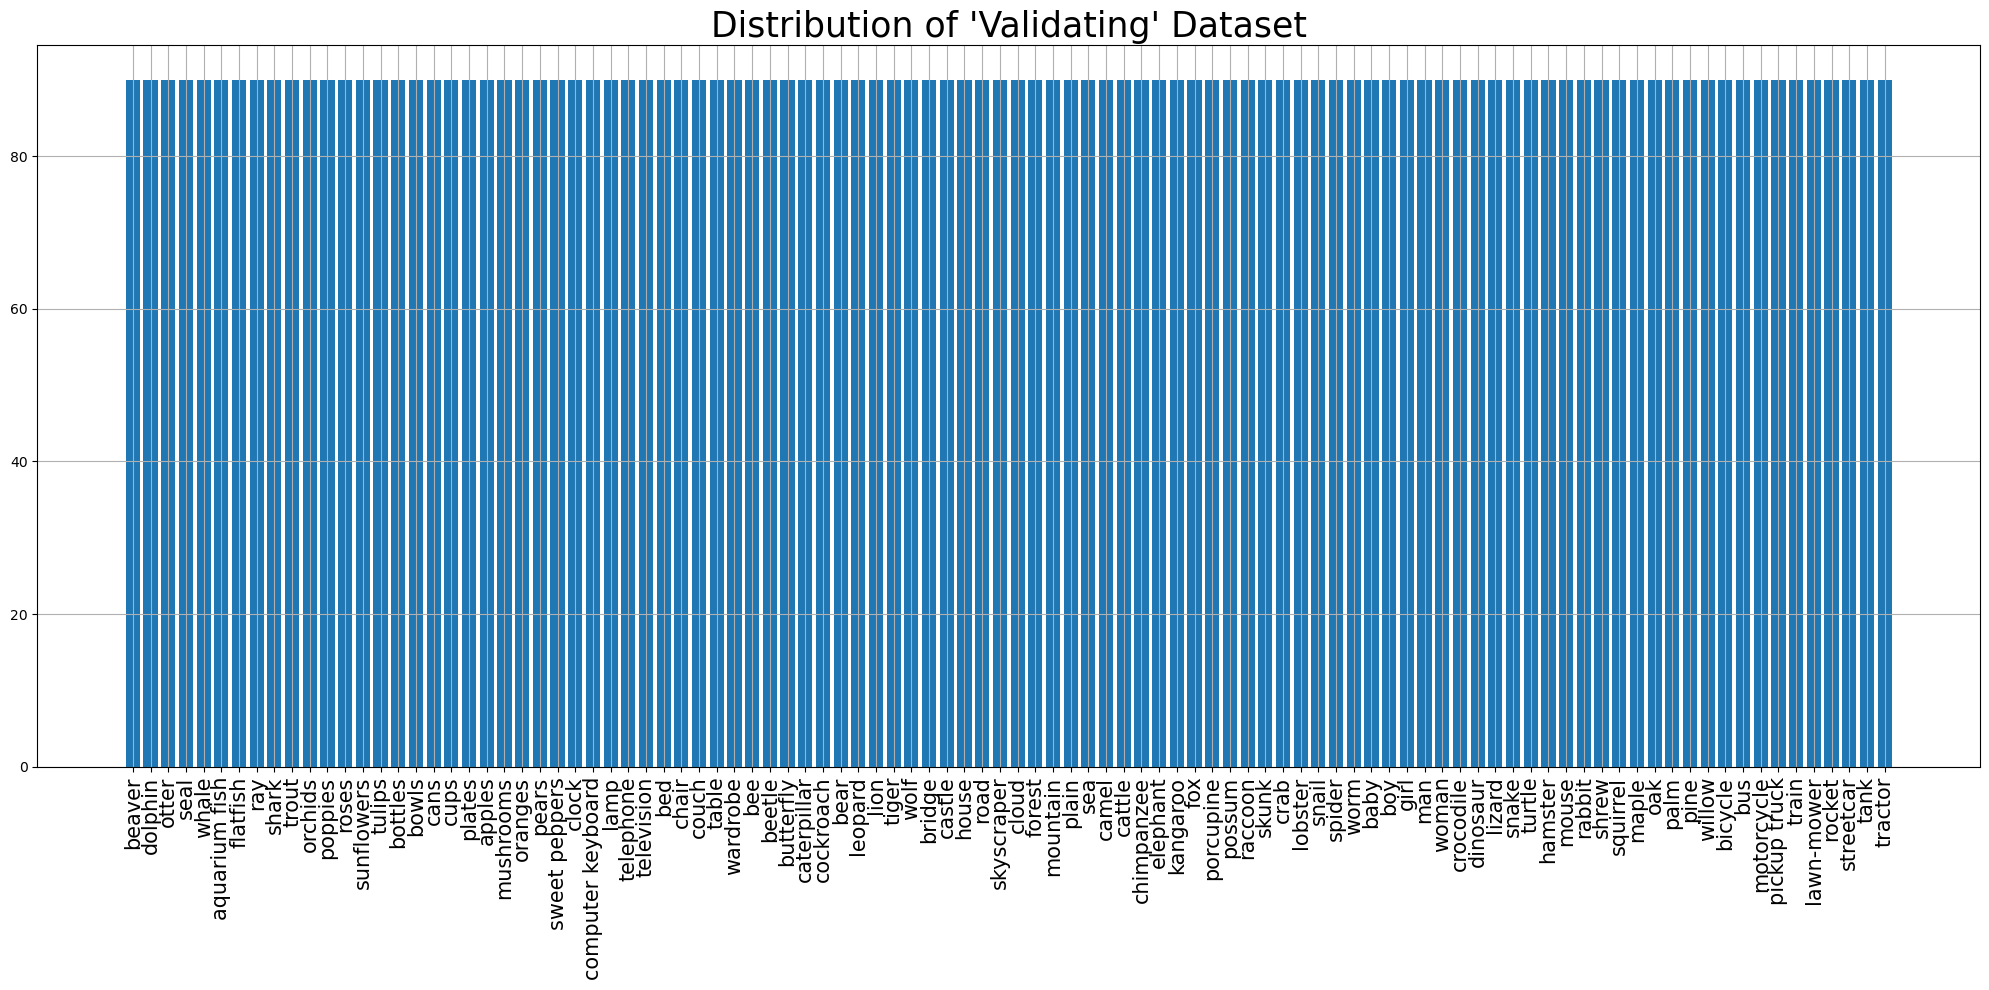

C:\Users\andre\AppData\Local\Temp\ipykernel_31204\1521307851.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_names, rotation=90, fontsize=15)


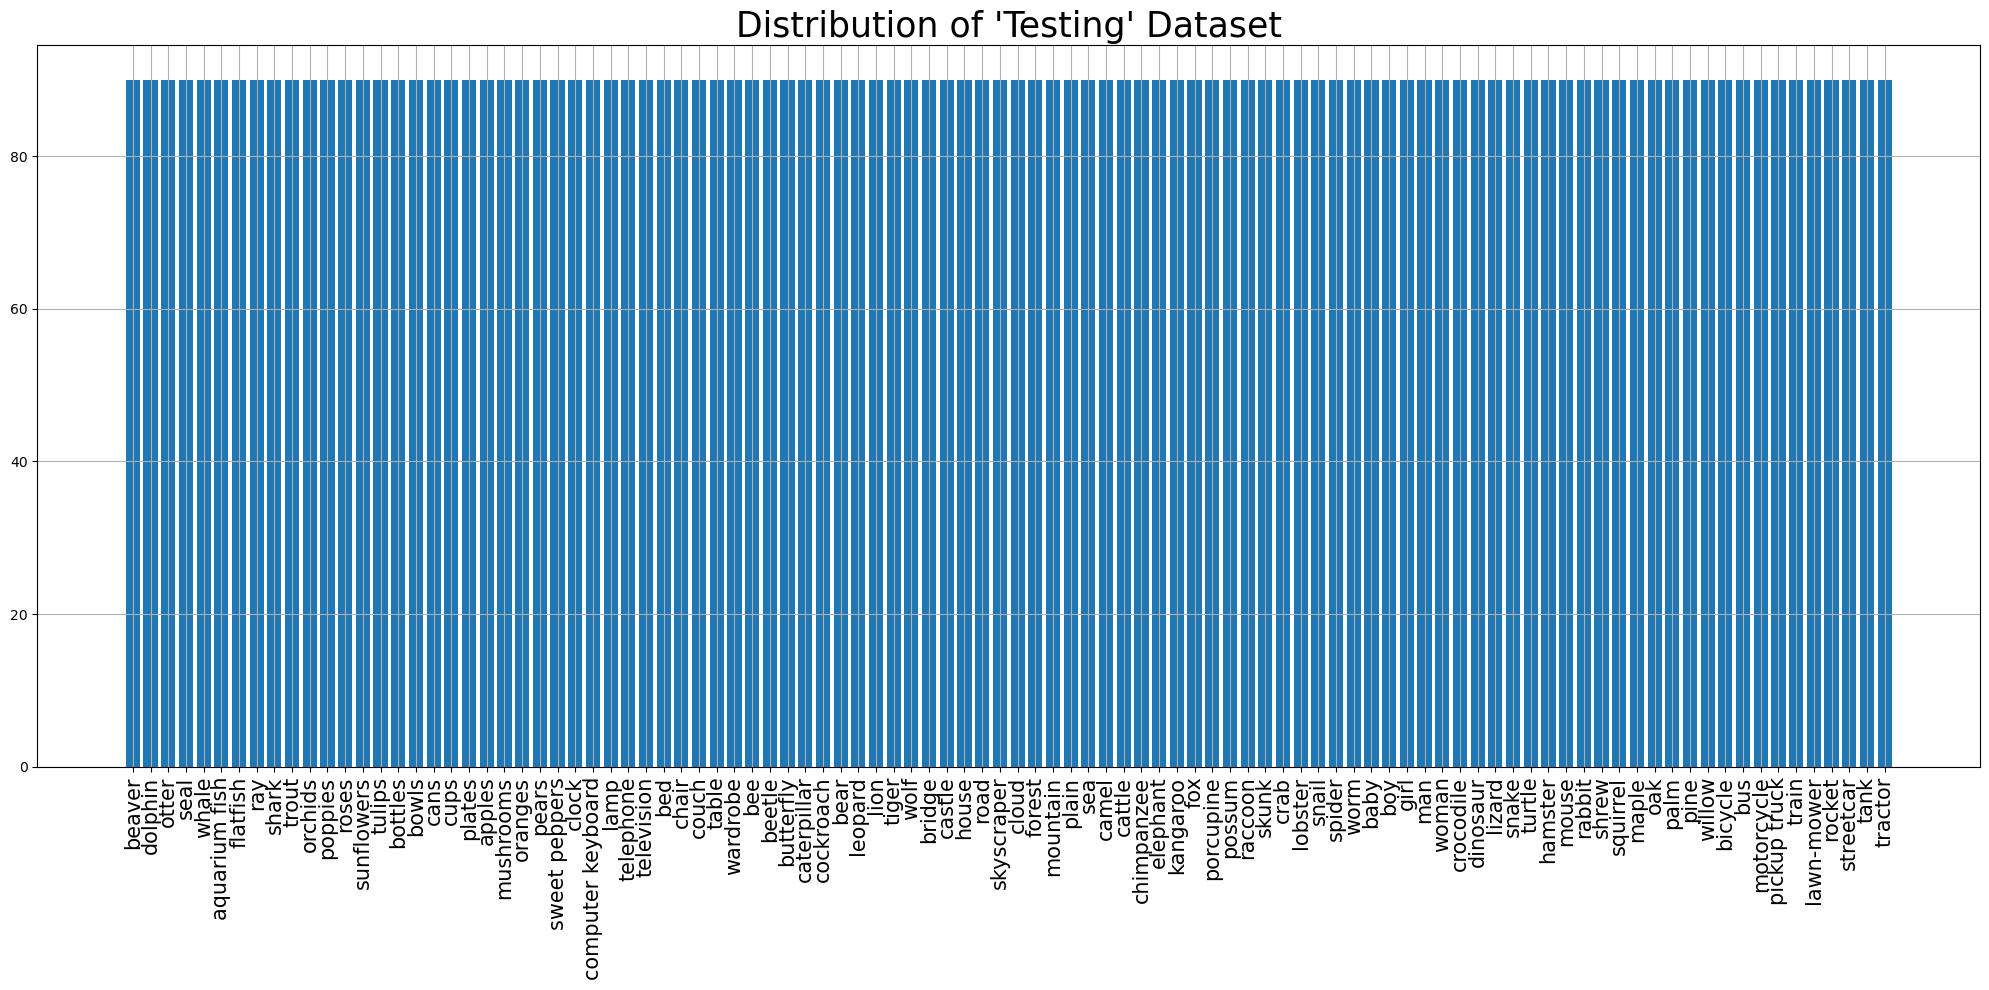

Training dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Validation dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)

Testing dataset:
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100), dtype=tf.float32, name=None))>
Image shape: (64, 224, 224, 3)
Label shape: (64, 100)


In [16]:
# Normalise images (scale to range [0, 1]) - Improves convergence speed & accuracy
X_train, X_val, X_test = X_train / 255.0, X_val / 255.0, X_test / 255.0
display_imgs_7(X_train, y_train)

labels_names = ['beaver','dolphin','otter','seal','whale','aquarium fish','flatfish','ray','shark','trout',
               'orchids','poppies','roses','sunflowers','tulips','bottles','bowls','cans','cups','plates',
               'apples','mushrooms','oranges','pears','sweet peppers','clock','computer keyboard','lamp',
               'telephone','television','bed','chair','couch','table','wardrobe','bee','beetle','butterfly',
               'caterpillar','cockroach','bear','leopard','lion','tiger','wolf','bridge','castle','house',
               'road','skyscraper','cloud','forest','mountain','plain','sea','camel','cattle','chimpanzee',
               'elephant','kangaroo','fox','porcupine','possum','raccoon','skunk','crab','lobster','snail',
               'spider','worm','baby','boy','girl','man','woman','crocodile','dinosaur','lizard','snake',
               'turtle','hamster','mouse','rabbit','shrew','squirrel','maple','oak','palm','pine','willow',
               'bicycle','bus','motorcycle','pickup truck','train','lawn-mower','rocket','streetcar','tank',
               'tractor']

class_distrib(y_train, labels_names, "Training")
class_distrib(y_val, labels_names, "Validating")
class_distrib(y_test, labels_names, "Testing")

# Create TensorFlow datasets

batch_size = 64

train_dataset_ = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
                 .map(lambda x, y: (tf.image.resize(x, (224, 224)),
                                    tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))))  # Remove extra dimension
                 .batch(batch_size)
                 .prefetch(tf.data.experimental.AUTOTUNE))

# DEBUG augment
#train_dataset_aug = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
#                 .map(augment_dataset, num_parallel_calls=tf.data.experimental.AUTOTUNE)
#                 .batch(batch_size)
#                 .prefetch(tf.data.experimental.AUTOTUNE))

# Combine the original dataset and the augmented dataset
train_dataset = train_dataset_#.concatenate(train_dataset_aug)

val_dataset = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
               .map(lambda x, y: (tf.image.resize(x, (224, 224)),
                                  tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))))  # Remove extra dimension
               .batch(batch_size)
               .prefetch(tf.data.experimental.AUTOTUNE))

test_dataset = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
                 .map(lambda x, y: (tf.image.resize(x, (224, 224)),
                                    tf.squeeze(tf.one_hot(y, depth=100, dtype=tf.float32))))  # Remove extra dimension
                .batch(batch_size)
                .prefetch(tf.data.experimental.AUTOTUNE))

print(f"Training dataset:\n {train_dataset}")
for img, lbl in train_dataset.take(1):
    #if isinstance(batch, tuple) and len(batch) == 2:
    print(f"Image shape: {img.shape}")  # Should be (batch_size, 224, 224, 3)
    print(f"Label shape: {lbl.shape}")  # Should be (batch_size, 10)
    del img,lbl
print(f"\nValidation dataset:\n {val_dataset}")
for img, lbl in val_dataset.take(1):
    #if isinstance(batch, tuple) and len(batch) == 2:
    print(f"Image shape: {img.shape}")  # Should be (batch_size, 224, 224, 3)
    print(f"Label shape: {lbl.shape}")  # Should be (batch_size, 10)
    del img,lbl
print(f"\nTesting dataset:\n {test_dataset}")
for img, lbl in test_dataset.take(1):
    #if isinstance(batch, tuple) and len(batch) == 2:
    print(f"Image shape: {img.shape}")  # Should be (batch_size, 224, 224, 3)
    print(f"Label shape: {lbl.shape}")  # Should be (batch_size, 10)
    del img,lbl

C:\Users\andre\anaconda3\envs\ml_env\lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")




In [17]:
# Load ResNet50 pre-trained on ImageNet (w/out the top classification layer which is designed for ImageNet (diff dataset))
resnet_50 = tf.keras.applications.ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Visualize model
visualkeras.layered_view(resnet_50, legend=True)

# Custom font for readability
font = ImageFont.truetype("arial.ttf", 18) # Adjust font size as needed
visualkeras.layered_view(resnet_50, legend=True, font=font)

In [18]:
image = visualkeras.layered_view(resnet_50, legend=True, font=font)
image.save("resnet50v2_visual.png")

random_labels: ['porcupine' 'willow' 'house' 'road' 'squirrel' 'bridge' 'beetle']
random_label_indices: [61, 89, 47, 48, 84, 45, 36]
label_idx: 61
selected_labels: [np.int64(40)]
label_idx: 89
selected_labels: [np.int64(40), np.int64(40)]
label_idx: 47
selected_labels: [np.int64(40), np.int64(40), np.int64(40)]
label_idx: 48
selected_labels: [np.int64(40), np.int64(40), np.int64(40), np.int64(40)]
label_idx: 84
selected_labels: [np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40)]
label_idx: 45
selected_labels: [np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40)]
label_idx: 36
selected_labels: [np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40)]


AttributeError: 'numpy.int64' object has no attribute 'capitalize'

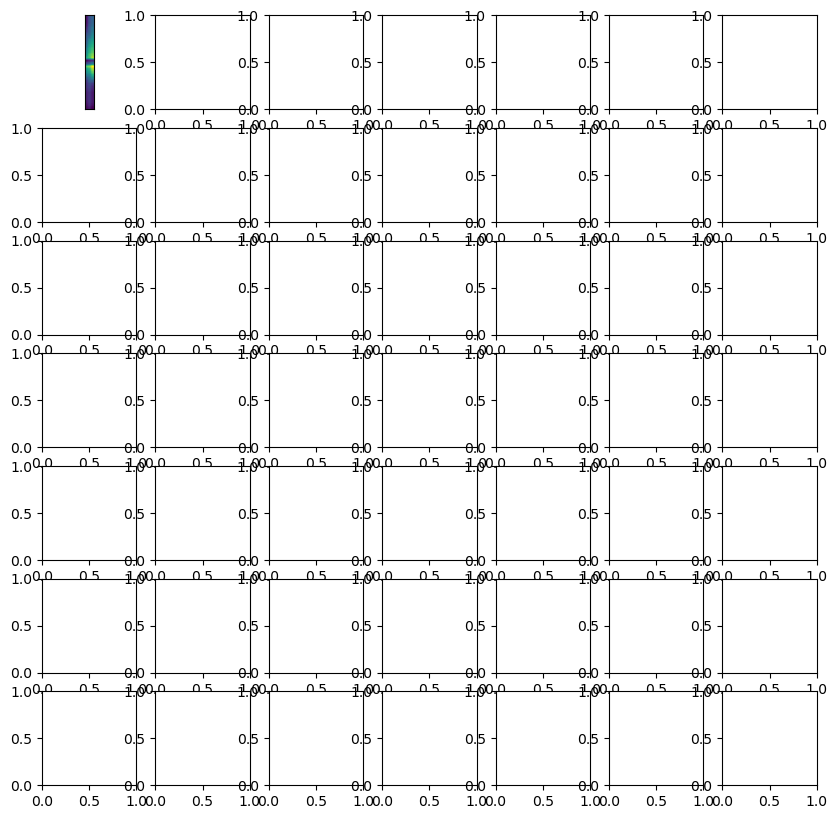

In [56]:
def display_imgs_7(imgs, labels):
    fig, axes = plt.subplots(7, 7, figsize = (10,10)) # 7x7 grid
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i])
        ax.set_xticks([]) # Remove x-axis ticks
        ax.set_yticks([]) # Remove y-axis ticks
        if i % 7 == 0:  # Only set label for the first image in each row
            ax.set_ylabel(labels[i].capitalize(), fontsize=15, weight='bold', rotation=0, labelpad=40, ha="right", va="center")
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    plt.suptitle(f"CIFAR-100 Examples", fontsize=20, y=0.92)
    plt.show()

(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode='fine')

labels_names = ['beaver','dolphin','otter','seal','whale','aquarium fish','flatfish','ray','shark','trout',
               'orchids','poppies','roses','sunflowers','tulips','bottles','bowls','cans','cups','plates',
               'apples','mushrooms','oranges','pears','sweet peppers','clock','computer keyboard','lamp',
               'telephone','television','bed','chair','couch','table','wardrobe','bee','beetle','butterfly',
               'caterpillar','cockroach','bear','leopard','lion','tiger','wolf','bridge','castle','house',
               'road','skyscraper','cloud','forest','mountain','plain','sea','camel','cattle','chimpanzee',
               'elephant','kangaroo','fox','porcupine','possum','raccoon','skunk','crab','lobster','snail',
               'spider','worm','baby','boy','girl','man','woman','crocodile','dinosaur','lizard','snake',
               'turtle','hamster','mouse','rabbit','shrew','squirrel','maple','oak','palm','pine','willow',
               'bicycle','bus','motorcycle','pickup truck','train','lawn-mower','rocket','streetcar','tank',
               'tractor']

# Choose 7 random unique labels
num_class = 7
random_labels = np.random.choice(labels_names, num_class, replace=False) # Store 7 random names
random_label_indices = [labels_names.index(label) for label in random_labels] # Find the indices for these names from the dictionary
print(f"random_labels: {random_labels}")
print(f"random_label_indices: {random_label_indices}")

# Select 7 images for each label
selected_images = []
selected_labels = []

for label_idx in random_label_indices:
    print(f"label_idx: {label_idx}")
    indices = np.where(y_train.flatten() == label_idx)[0]  # Get indices of images with this label
    #print(f"indices: {indices}")
    chosen_indices = np.random.choice(indices, num_class, replace=False)  # Pick 7 random images
    #for chosen_indice in chosen_indices:
        #print(f"chosen_indice: {chosen_indice}")
        #print(f"y_train[chosen_indice]: {labels_names[y_train[chosen_indice][0]]}") - up to here is correct
    selected_images.append(X_train[chosen_indice][0])
    selected_labels.append(y_train[chosen_indice][0])
    print(f"selected_labels: {selected_labels}")
    #selected_images.extend(X_train[chosen_indices])
    #selected_labels.extend([labels_names[label_idx]] * 7)

# Convert to NumPy array
#selected_images = np.array(selected_images).

# Display the selected images
display_imgs_7(selected_images, selected_labels)